# Chapter 9: modeling probabilities and nonlinearities: activation functions

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- What is an activation function?
- Standard hidden activation functions
  - Sigmoid
  - Tanh
- Standard output activation functions
  - Softmax
- Activation function installation instructions

## What is an activation function?

Activation function adalah function yang diterapkan pada neurons dalam sebuah layer saat prediction.

Contoh activation function yang sudah dipakai sebelumnya adalah `relu`. Fungsi `relu` mengubah semua angka negatif menjadi 0.

Secara sangat sederhana, activation function adalah function yang menerima satu angka dan mengembalikan angka lain. Namun, tidak semua function cocok dijadikan activation function.

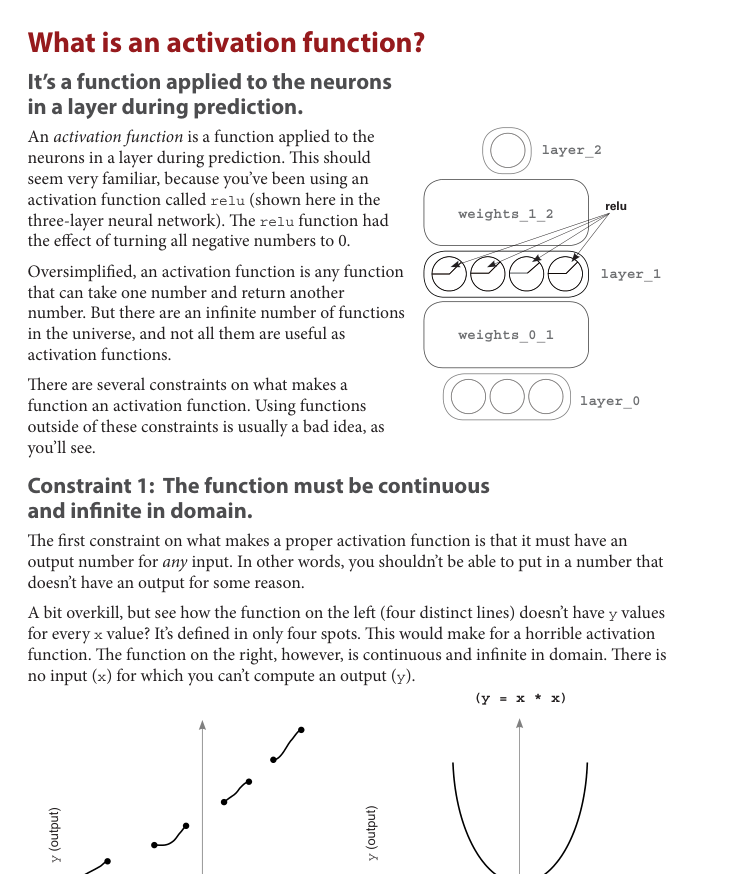

Activation function yang baik memiliki beberapa constraint.

Constraint pertama: function harus continuous dan infinite in domain. Artinya, untuk setiap input harus ada output. Function yang hanya memiliki output pada beberapa titik tertentu buruk untuk activation function. Function yang continuous dan memiliki output untuk semua nilai input lebih cocok.

Constraint kedua: activation function yang baik biasanya monotonic, yaitu tidak berubah arah. Function harus selalu meningkat atau selalu menurun. Jika banyak input berbeda menghasilkan output yang sama, optimization menjadi lebih sulit karena network memiliki banyak kemungkinan konfigurasi yang sama-sama benar.

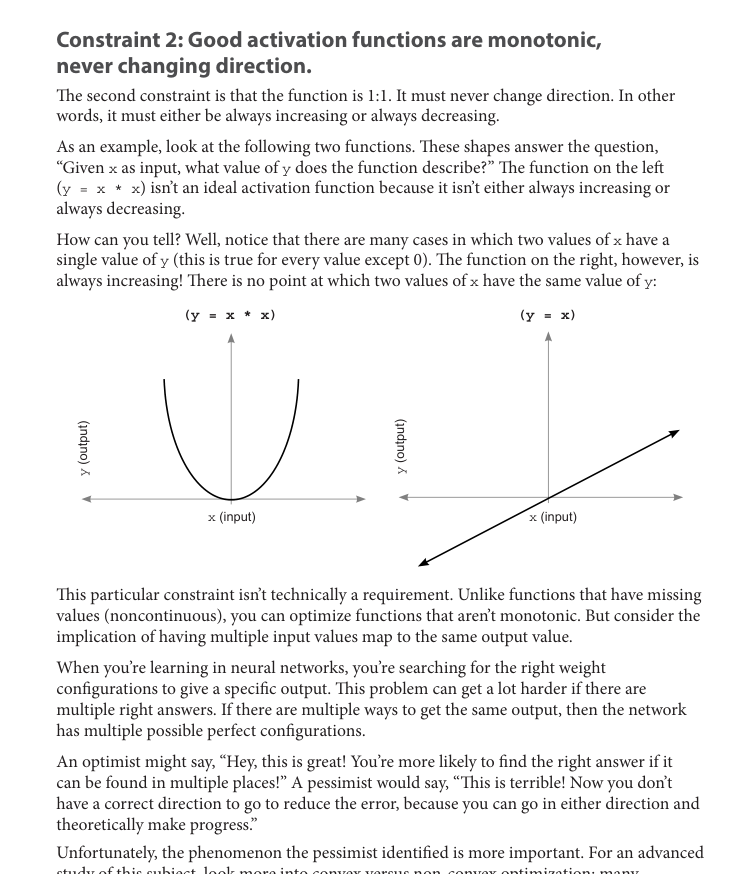

Constraint ketiga: activation function yang baik bersifat nonlinear. Function nonlinear memiliki curve atau belokan.

Nonlinearity diperlukan untuk selective correlation. Jika activation function hanya berupa garis lurus, maka function tersebut hanya melakukan scaling terhadap weighted average yang masuk. Scaling tidak mengubah cara neuron berkorelasi dengan input.

Dengan function yang melengkung, incoming signal dapat meningkatkan atau menurunkan cara neuron berkorelasi terhadap incoming signal lain.

Constraint keempat: activation function dan derivative-nya harus dapat dihitung secara efisien. Function ini akan dipanggil sangat sering, sehingga tidak boleh terlalu lambat.

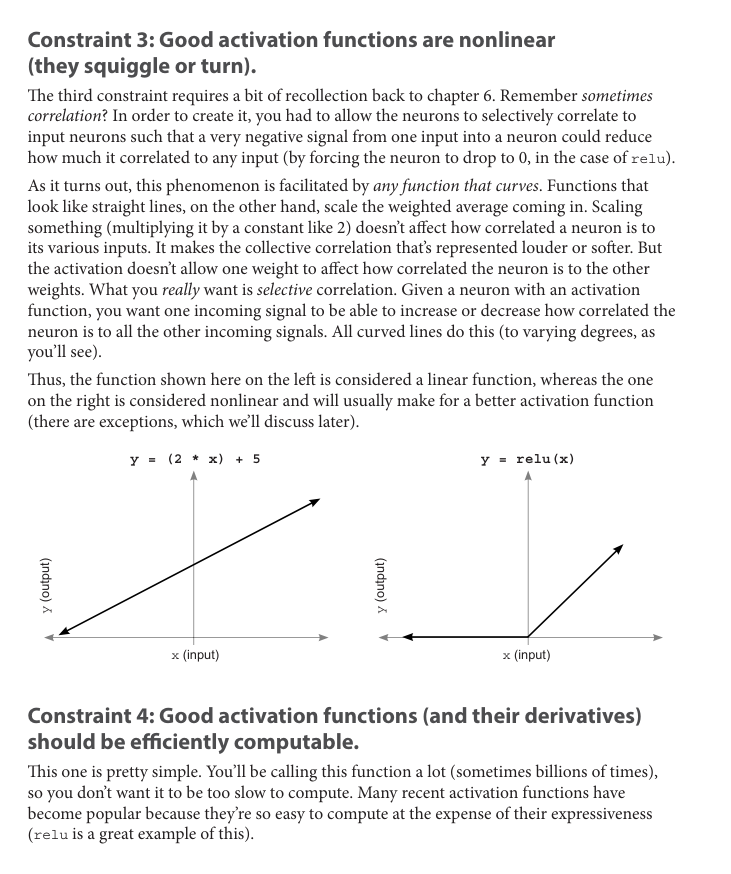

## Standard hidden-layer activation functions

Ada banyak function yang mungkin dipakai sebagai activation function, tetapi hanya sebagian kecil yang umum dipakai.

`sigmoid` adalah activation function dasar yang sering digunakan. Sigmoid mengubah input tak terbatas menjadi output antara 0 dan 1. Dalam banyak keadaan, output neuron dapat diinterpretasikan sebagai probability.

`tanh` mirip sigmoid, tetapi output-nya berada antara -1 dan 1. Karena itu, `tanh` dapat memodelkan positive correlation dan negative correlation. Untuk hidden layer, `tanh` sering lebih baik daripada sigmoid.

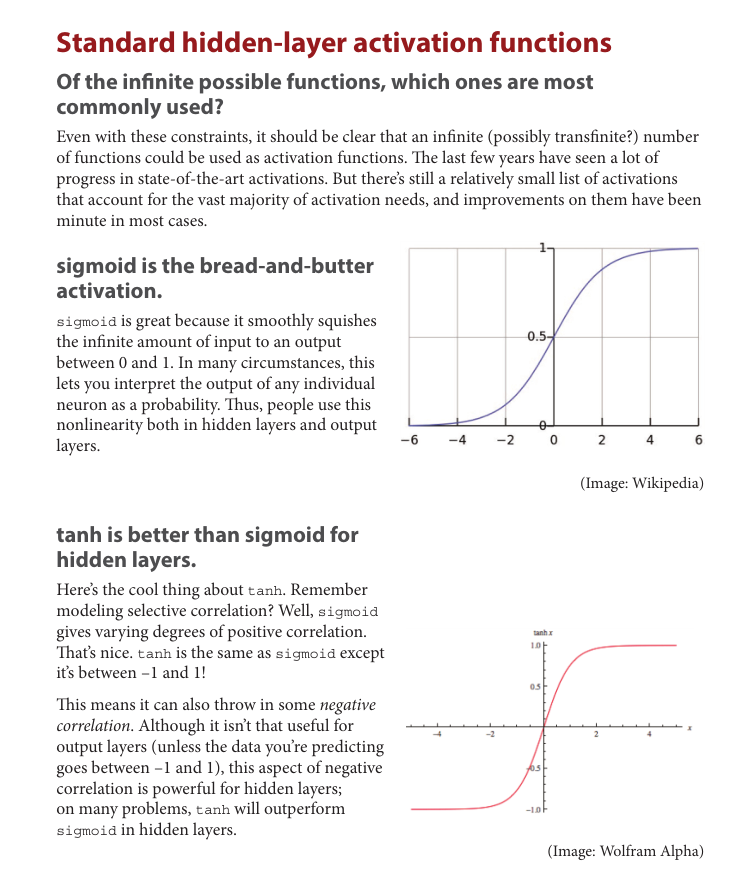

In [1]:
import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

x = np.array([-3, -1, 0, 1, 3])

print("x:", x)
print("sigmoid(x):", sigmoid(x))
print("tanh(x):", tanh(x))

x: [-3 -1  0  1  3]
sigmoid(x): [0.04742587 0.26894142 0.5        0.73105858 0.95257413]
tanh(x): [-0.99505475 -0.76159416  0.          0.76159416  0.99505475]


## Standard output layer activation functions

Activation function terbaik untuk output layer bergantung pada hal yang ingin diprediksi.

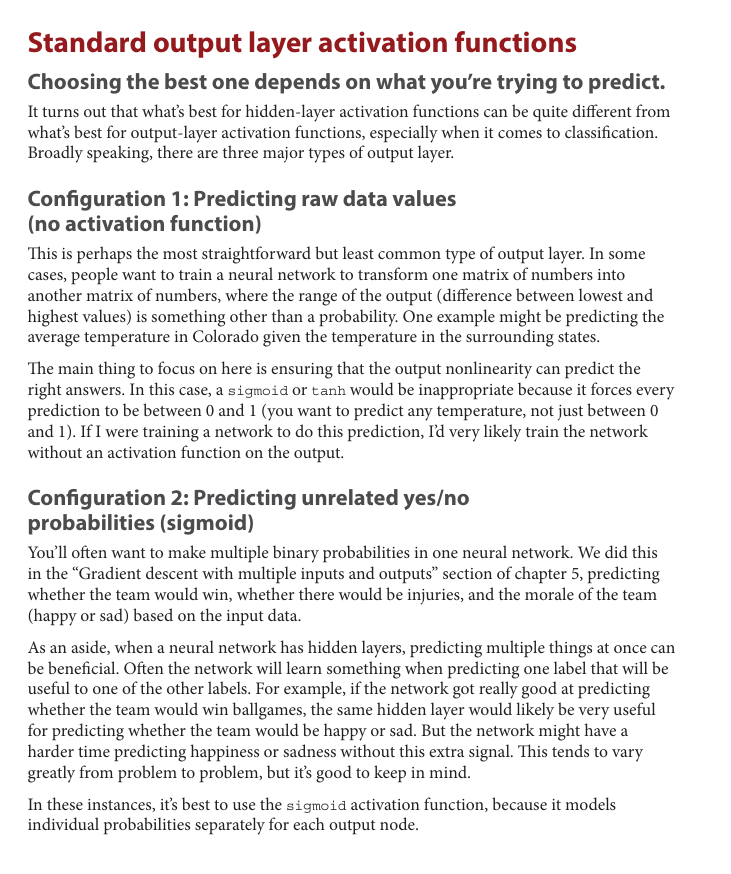

## Configuration 1: Predicting raw data values

Pada konfigurasi ini, output layer tidak memakai activation function.

Ini digunakan ketika network perlu mengubah satu matrix angka menjadi matrix angka lain, dan range output bukan probability. Contohnya adalah memprediksi temperatur rata-rata di Colorado berdasarkan temperatur negara bagian di sekitarnya.

Sigmoid atau tanh tidak cocok untuk kasus seperti ini karena memaksa prediction berada dalam range tertentu, sedangkan temperatur bisa berada di luar range 0 sampai 1 atau -1 sampai 1.

In [2]:
import numpy as np

raw_output = np.array([[12.5, 24.0, -3.2]])
print(raw_output)

[[12.5 24.  -3.2]]


## Configuration 2: Predicting unrelated yes/no probabilities

Pada konfigurasi ini, output layer memakai `sigmoid`.

Ini dipakai ketika network ingin membuat beberapa binary probabilities yang tidak harus saling bergantung. Contohnya adalah memprediksi apakah tim menang, apakah ada cedera, dan apakah morale tim sad/happy.

Sigmoid cocok karena memodelkan probability secara terpisah untuk setiap output node.

In [3]:
import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

raw_output = np.array([[-2.0, 0.0, 3.0]])
probabilities = sigmoid(raw_output)

print(probabilities)

[[0.11920292 0.5        0.95257413]]


## Configuration 3: Predicting which-one probabilities

Kasus paling umum dalam neural network adalah memprediksi satu label dari banyak label. Contohnya MNIST digit classifier, yaitu memprediksi digit mana yang ada dalam image.

Untuk kasus ini, activation function yang sesuai adalah `softmax`. Softmax memodelkan ide bahwa semakin mungkin satu label, semakin kecil kemungkinan label lainnya.

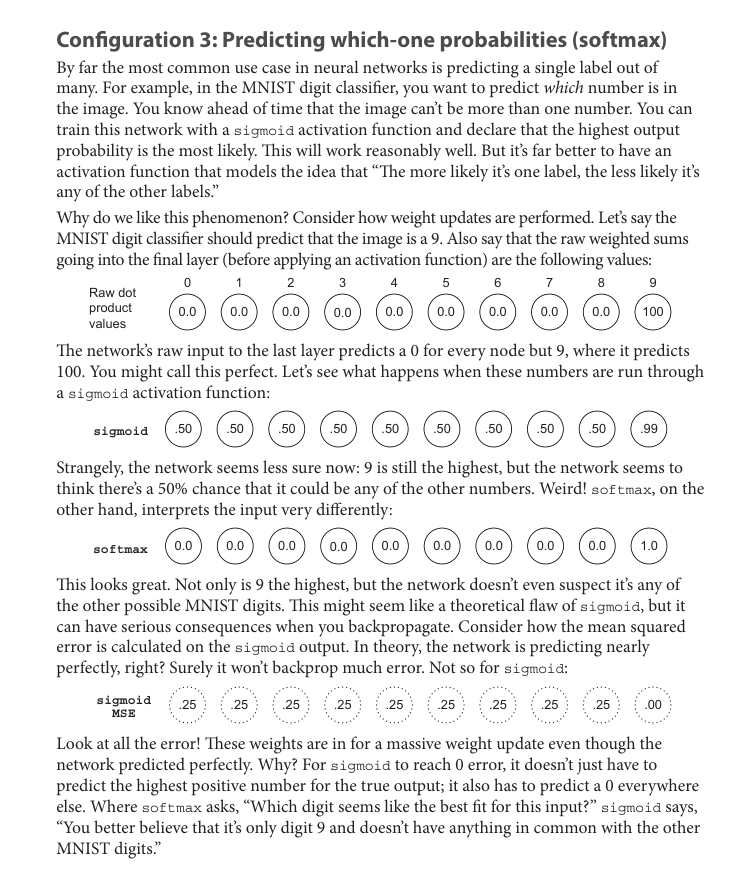

In [4]:
import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def softmax(x):
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

raw = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 100]])

print("sigmoid:", sigmoid(raw))
print("softmax:", softmax(raw))

sigmoid: [[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1. ]]
softmax: [[3.72007598e-44 3.72007598e-44 3.72007598e-44 3.72007598e-44
  3.72007598e-44 3.72007598e-44 3.72007598e-44 3.72007598e-44
  3.72007598e-44 1.00000000e+00]]


Pada contoh raw dot product, nilai untuk label 9 sangat tinggi, sedangkan label lain 0. Sigmoid tetap menghasilkan sekitar 0.5 pada label-label lain. Softmax menghasilkan probability yang terkonsentrasi pada label 9.

Masalah sigmoid pada kasus which-one adalah error tetap besar untuk label lain yang output-nya 0.5, walaupun label benar sudah menjadi output tertinggi. Softmax lebih cocok karena menilai persaingan antar label.

## The core issue: Inputs have similarity

Input yang berbeda dapat memiliki similarity.

Digit MNIST tidak sepenuhnya berbeda. Digit 2 dan 3 dapat memiliki pixel yang mirip, terutama pada bagian curve. Jika sigmoid dipakai untuk output classification, network dapat diberi penalti besar hanya karena mengenali fitur yang juga muncul pada label lain.

Softmax lebih sesuai karena tidak menghukum label yang mirip dengan cara yang sama. Softmax juga menghasilkan probabilities yang totalnya berjumlah 1, sehingga setiap prediction dapat dibaca sebagai global probability untuk suatu label.

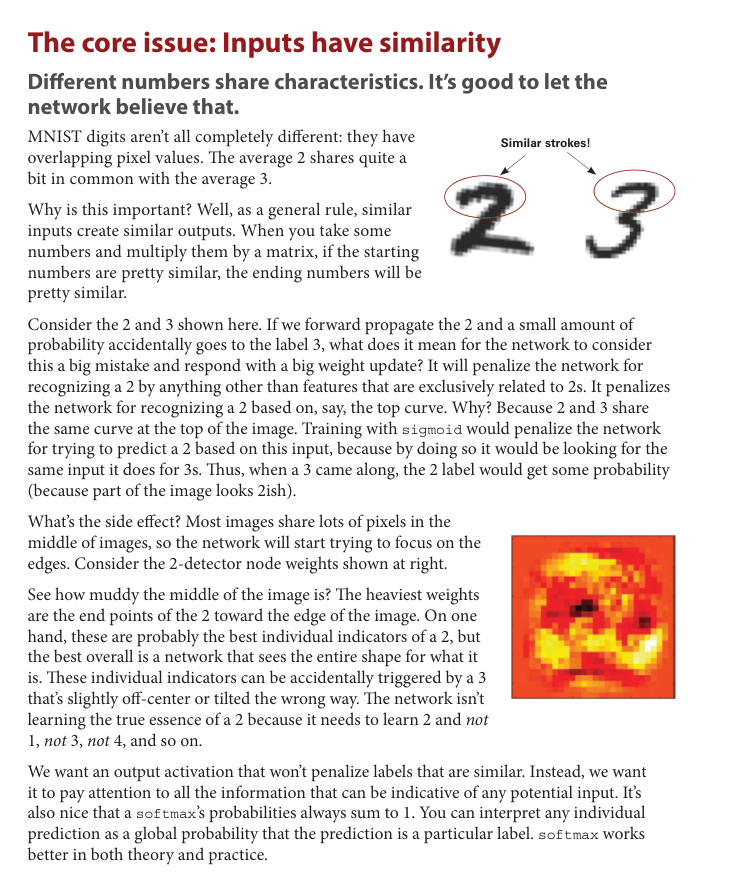

## softmax computation

Softmax menaikkan setiap input secara exponential, lalu membagi setiap nilai dengan jumlah seluruh nilai pada layer.

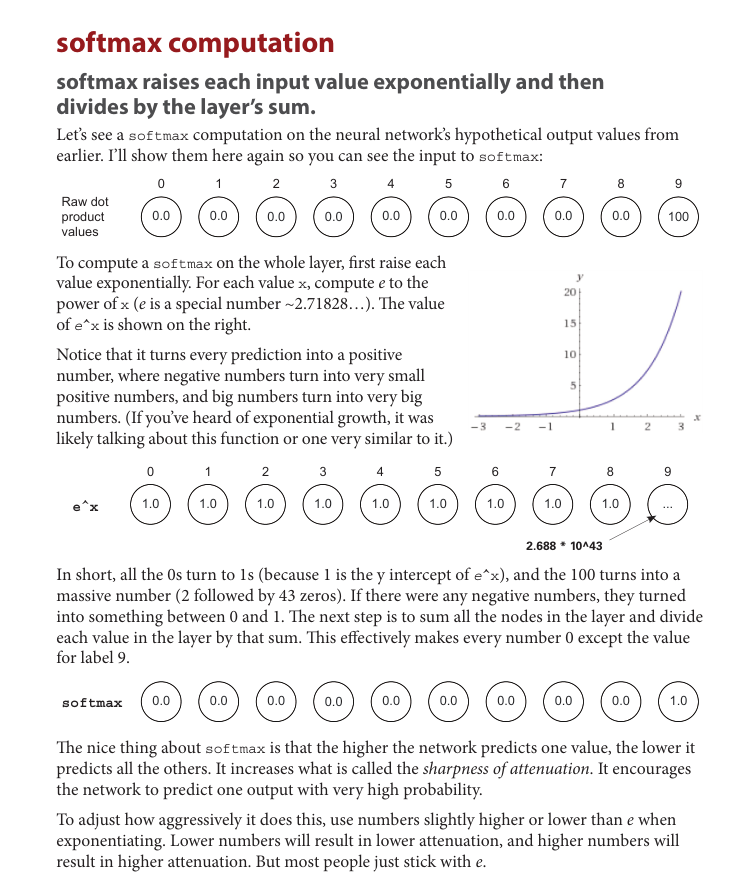

In [5]:
import numpy as np

def softmax(x):
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

raw = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 100]])
exp_values = np.exp(raw)
softmax_values = softmax(raw)

print("exp values:", exp_values)
print("softmax:", softmax_values)
print("sum softmax:", np.sum(softmax_values))

exp values: [[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 2.68811714e+43]]
softmax: [[3.72007598e-44 3.72007598e-44 3.72007598e-44 3.72007598e-44
  3.72007598e-44 3.72007598e-44 3.72007598e-44 3.72007598e-44
  3.72007598e-44 1.00000000e+00]]
sum softmax: 1.0


Langkah softmax:

1. Hitung `e^x` untuk setiap nilai.
2. Jumlahkan semua hasil exponential pada layer.
3. Bagi setiap nilai exponential dengan jumlah tersebut.

Hasilnya, nilai yang sangat besar mendapat probability hampir 1, sedangkan nilai lain mendekati 0. Softmax membuat probability output saling bersaing.

## Activation installation instructions

Activation function dipasang pada forward propagation dengan menerapkan function tersebut pada input layer.

Contoh pada hidden layer:

`layer_1 = relu(np.dot(layer_0, weights_0_1))`

Input ke `layer_1` adalah hasil `np.dot(layer_0, weights_0_1)`, lalu activation function `relu` diterapkan pada hasil tersebut.

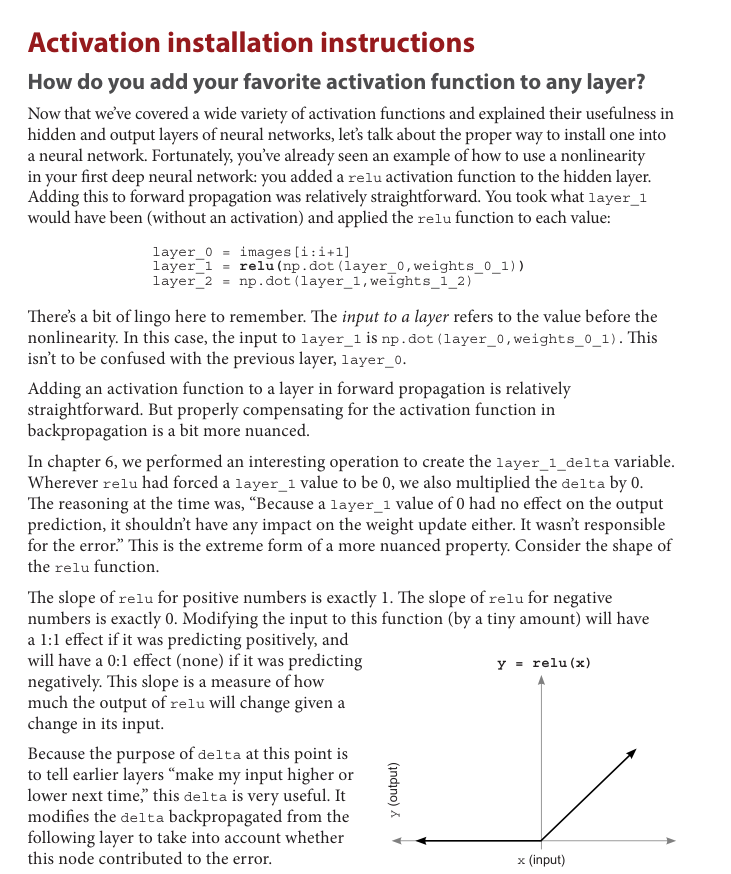

In [6]:
import numpy as np

def relu(x):
  return (x >= 0) * x

layer_0 = np.array([[1, 0, 1]])
weights_0_1 = np.array([
  [0.5, -0.2, 0.1],
  [0.1, 0.3, -0.4],
  [-0.6, 0.2, 0.7]
])

layer_1_input = np.dot(layer_0, weights_0_1)
layer_1 = relu(layer_1_input)

print("layer_1_input:", layer_1_input)
print("layer_1:", layer_1)

layer_1_input: [[-0.1  0.   0.8]]
layer_1: [[-0.   0.   0.8]]


Saat backpropagation, activation function perlu dikompensasi dengan derivative-nya.

Pada `relu`, jika output dibuat 0, node tersebut tidak berkontribusi pada output prediction. Karena itu, delta pada node tersebut juga dibuat 0.

Slope `relu` untuk angka positif adalah 1, sedangkan untuk angka negatif adalah 0. Delta dari layer berikutnya dikalikan dengan slope ini agar update weight hanya terjadi pada node yang memang berkontribusi.

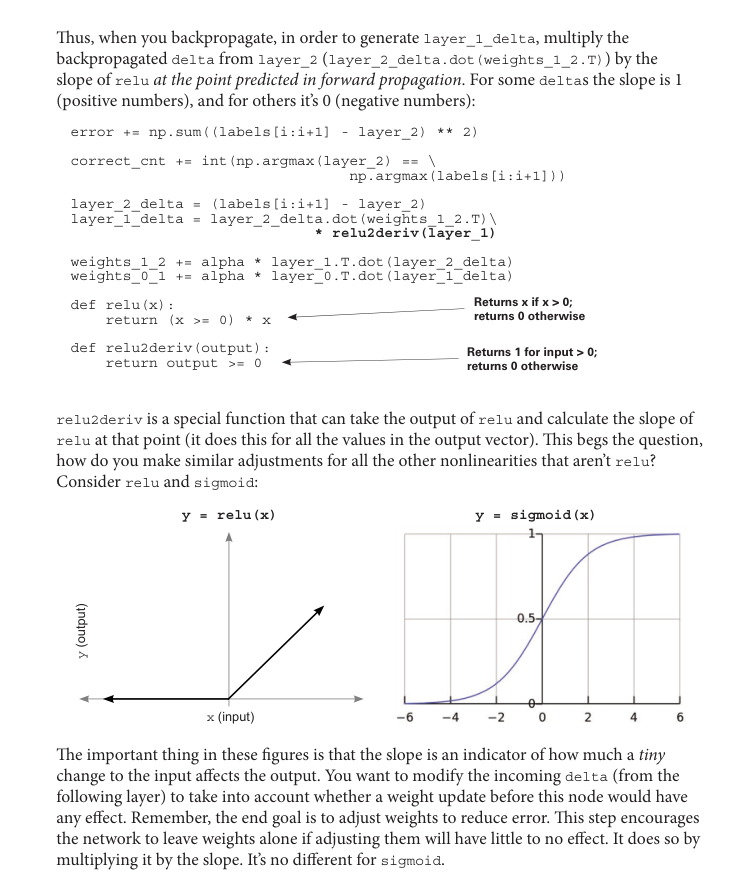

In [7]:
import numpy as np

def relu(x):
  return (x >= 0) * x

def relu2deriv(output):
  return output >= 0

x = np.array([[-2, -1, 0, 1, 2]])
output = relu(x)
derivative = relu2deriv(output)

print("relu output:", output)
print("relu derivative:", derivative)

relu output: [[0 0 0 1 2]]
relu derivative: [[ True  True  True  True  True]]


## Multiplying delta by the slope

Untuk menghitung `layer_delta`, backpropagated delta dikalikan dengan slope layer tersebut.

Tanpa nonlinearity, delta pada neuron adalah weighted average delta dari layer berikutnya. Dengan activation function, delta harus memperhitungkan apakah perubahan pada input neuron akan memengaruhi output neuron.

Pada sigmoid, sensitivity terhadap perubahan input meningkat ketika input mendekati 0. Ketika input sangat positif atau sangat negatif, slope mendekati 0. Artinya, perubahan kecil pada incoming weights tidak terlalu relevan terhadap error untuk training example tersebut.

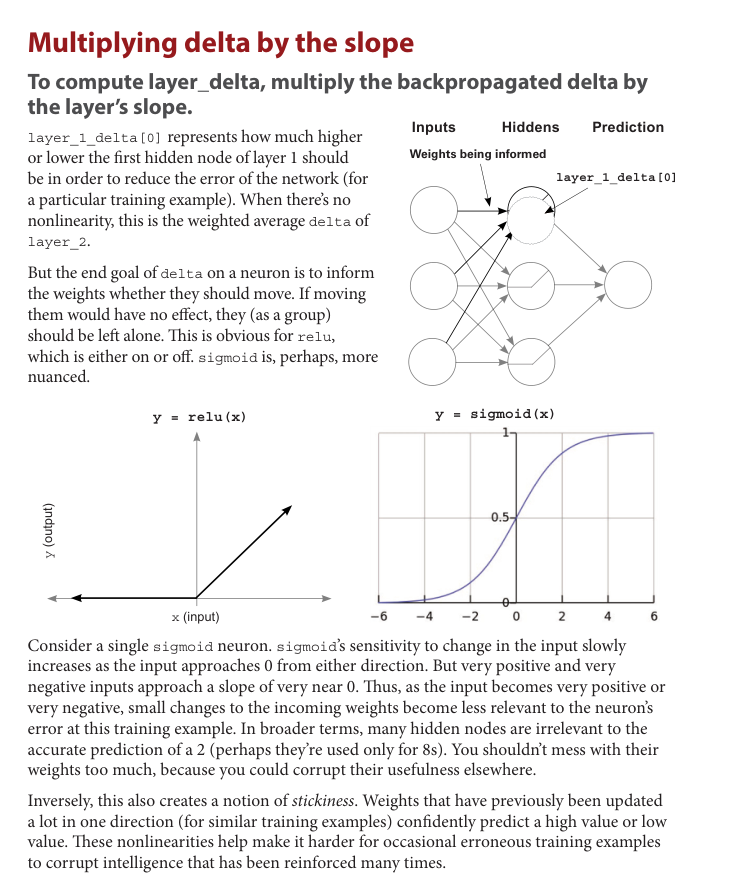

## Converting output to slope (derivative)

Activation function populer biasanya dapat menghitung derivative dari output-nya sendiri. Ini efisien karena output activation sudah dihitung pada forward propagation.

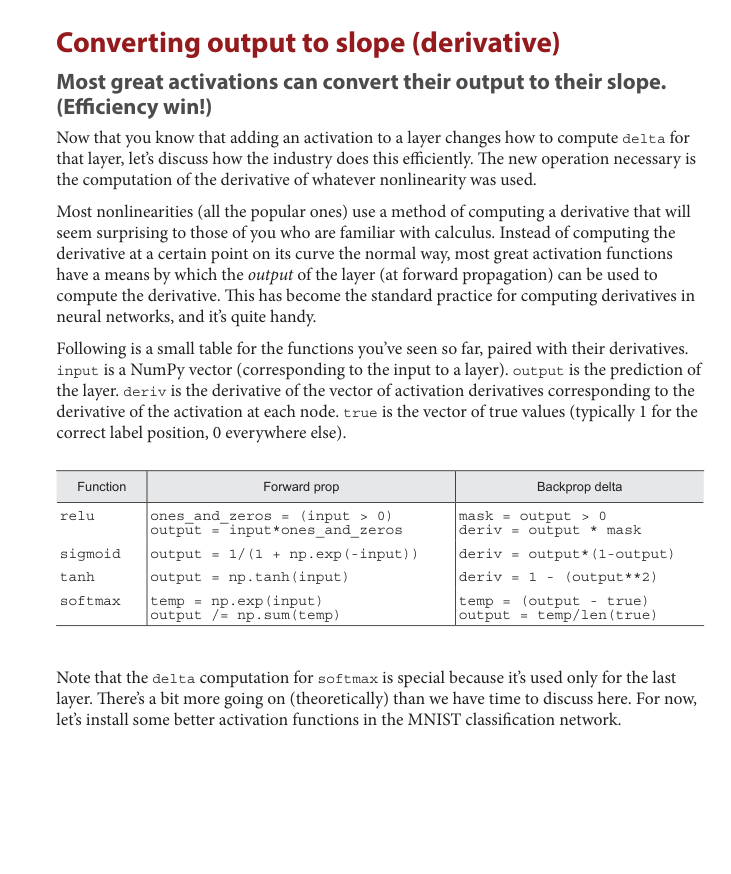

In [8]:
import numpy as np

def relu(x):
  ones_and_zeros = (x > 0)
  return x * ones_and_zeros

def relu2deriv(output):
  return output > 0

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid2deriv(output):
  return output * (1 - output)

def tanh(x):
  return np.tanh(x)

def tanh2deriv(output):
  return 1 - (output ** 2)

def softmax(x):
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

x = np.array([[-2.0, -1.0, 0.0, 1.0, 2.0]])

relu_output = relu(x)
sigmoid_output = sigmoid(x)
tanh_output = tanh(x)

print("relu:", relu_output)
print("relu derivative:", relu2deriv(relu_output))
print("sigmoid:", sigmoid_output)
print("sigmoid derivative:", sigmoid2deriv(sigmoid_output))
print("tanh:", tanh_output)
print("tanh derivative:", tanh2deriv(tanh_output))
print("softmax:", softmax(x))

relu: [[-0. -0.  0.  1.  2.]]
relu derivative: [[False False False  True  True]]
sigmoid: [[0.11920292 0.26894142 0.5        0.73105858 0.88079708]]
sigmoid derivative: [[0.10499359 0.19661193 0.25       0.19661193 0.10499359]]
tanh: [[-0.96402758 -0.76159416  0.          0.76159416  0.96402758]]
tanh derivative: [[0.07065082 0.41997434 1.         0.41997434 0.07065082]]
softmax: [[0.01165623 0.03168492 0.08612854 0.23412166 0.63640865]]


Pada tabel buku, bagian softmax bersifat khusus karena softmax dipakai pada output layer. Delta softmax yang digunakan pada network berikutnya adalah hasil perbandingan antara prediction dan true labels.

Pada implementasi notebook ini, derivative untuk `relu` dibuat sebagai mask `output > 0`, sesuai penjelasan slope relu.

## Upgrading the MNIST network

Network MNIST di-upgrade menggunakan `tanh` untuk hidden layer dan `softmax` untuk output layer.

Secara teori, `tanh` lebih baik untuk hidden-layer activation, sedangkan `softmax` lebih baik untuk output-layer activation pada classification banyak label. Untuk `tanh`, random initialization weights dibuat lebih sempit, yaitu antara -0.01 dan 0.01. Alpha juga perlu diatur ulang.

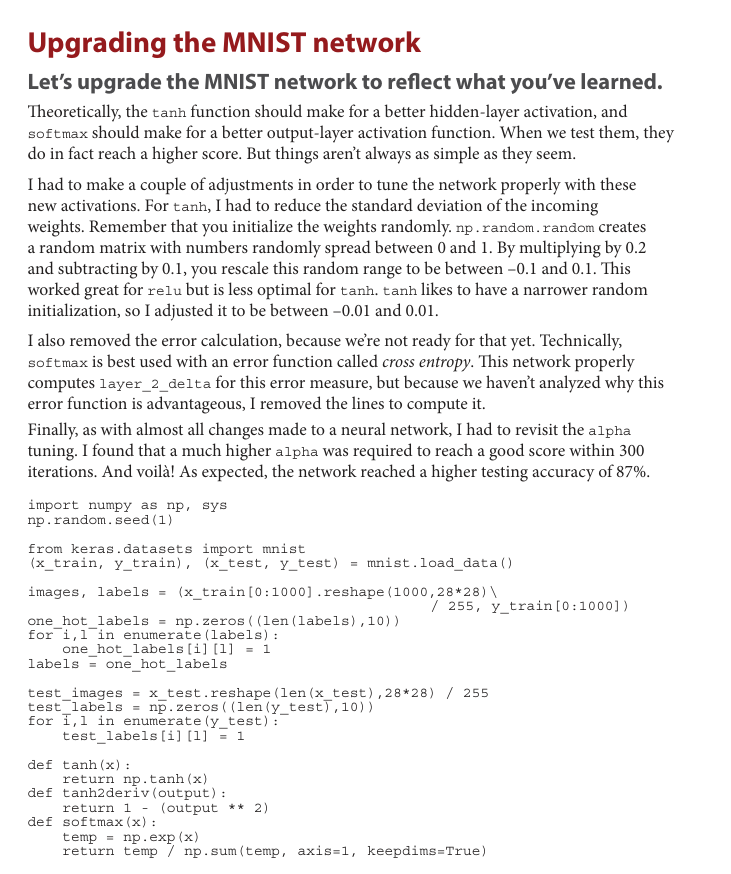

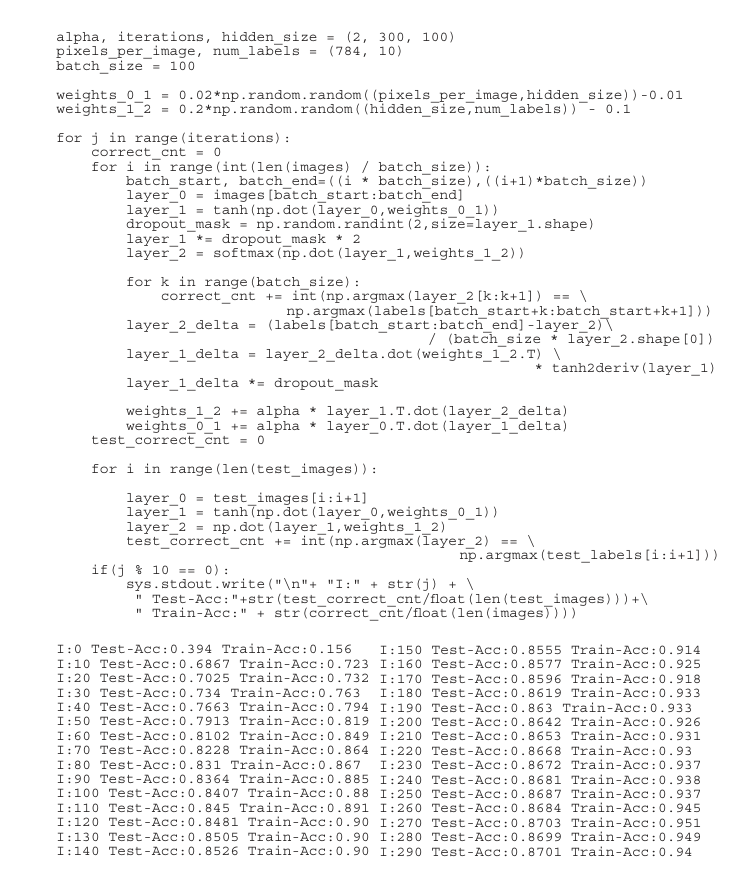

In [9]:
import numpy as np
import sys
from tensorflow.keras.datasets import mnist

np.random.seed(1)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

def tanh(x):
  return np.tanh(x)

def tanh2deriv(output):
  return 1 - (output ** 2)

def softmax(x):
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

alpha, iterations, hidden_size = (2, 300, 100)
pixels_per_image, num_labels = (784, 10)
batch_size = 100

weights_0_1 = 0.02 * np.random.random((pixels_per_image, hidden_size)) - 0.01
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  correct_cnt = 0

  for i in range(int(len(images) / batch_size)):
    batch_start = i * batch_size
    batch_end = (i + 1) * batch_size

    layer_0 = images[batch_start:batch_end]
    layer_1 = tanh(np.dot(layer_0, weights_0_1))

    dropout_mask = np.random.randint(2, size=layer_1.shape)
    layer_1 *= dropout_mask * 2

    layer_2 = softmax(np.dot(layer_1, weights_1_2))

    for k in range(batch_size):
      correct_cnt += int(
        np.argmax(layer_2[k:k + 1]) ==
        np.argmax(labels[batch_start + k:batch_start + k + 1])
      )

    layer_2_delta = (labels[batch_start:batch_end] - layer_2) / (batch_size * layer_2.shape[0])
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * tanh2deriv(layer_1)
    layer_1_delta *= dropout_mask

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

  test_correct_cnt = 0

  for i in range(len(test_images)):
    layer_0 = test_images[i:i + 1]
    layer_1 = tanh(np.dot(layer_0, weights_0_1))
    layer_2 = softmax(np.dot(layer_1, weights_1_2))

    test_correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

  if j % 10 == 0:
    print(
      "I:" + str(j) +
      " Test-Acc:" + str(test_correct_cnt / float(len(test_images))) +
      " Train-Acc:" + str(correct_cnt / float(len(images)))
    )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
I:0 Test-Acc:0.394 Train-Acc:0.156
I:10 Test-Acc:0.6867 Train-Acc:0.723
I:20 Test-Acc:0.7025 Train-Acc:0.732
I:30 Test-Acc:0.734 Train-Acc:0.763
I:40 Test-Acc:0.7663 Train-Acc:0.794
I:50 Test-Acc:0.7913 Train-Acc:0.819
I:60 Test-Acc:0.8102 Train-Acc:0.849
I:70 Test-Acc:0.8228 Train-Acc:0.864
I:80 Test-Acc:0.831 Train-Acc:0.867
I:90 Test-Acc:0.8364 Train-Acc:0.885
I:100 Test-Acc:0.8407 Train-Acc:0.883
I:110 Test-Acc:0.845 Train-Acc:0.891
I:120 Test-Acc:0.8481 Train-Acc:0.901
I:130 Test-Acc:0.8505 Train-Acc:0.901
I:140 Test-Acc:0.8526 Train-Acc:0.905
I:150 Test-Acc:0.8555 Train-Acc:0.914
I:160 Test-Acc:0.8577 Train-Acc:0.925
I:170 Test-Acc:0.8596 Train-Acc:0.918
I:180 Test-Acc:0.8619 Train-Acc:0.933
I:190 Test-Acc:0.863 Train-Acc:0.933
I:200 Test-Acc:0.8642 Train-Acc:0.926
I:210 Test-Acc:0.8653 Train-Acc:0.931
I:220 Test-Acc:0.8668 Train-Acc:0.93
I:230 Test-Acc:0.8672 Train-Acc:0.937
I:240 Test-Acc:0.8681 Train-Acc:0.938
I:250 Test-Acc:0

Pada kode buku, testing forward pass menampilkan `np.dot(layer_1, weights_1_2)` tanpa `softmax`. Notebook ini memakai `softmax` juga pada testing agar forward propagation konsisten dengan output activation yang sedang dibahas.

## Summary

Chapter ini membahas activation functions untuk memodelkan probabilities dan nonlinearities.

Activation function adalah function yang diterapkan pada neurons saat prediction. Activation function yang baik biasanya continuous, monotonic, nonlinear, dan efisien dihitung. Untuk hidden layer, sigmoid dan tanh adalah activation functions standar, dengan tanh sering lebih baik karena dapat merepresentasikan negative correlation. Untuk output layer, pilihan activation bergantung pada task: raw value prediction dapat tanpa activation, unrelated yes/no probabilities cocok dengan sigmoid, dan which-one classification cocok dengan softmax.

Saat activation function dipakai, backpropagation perlu mengalikan delta dengan derivative activation function. Chapter ini juga meng-upgrade MNIST network dengan tanh pada hidden layer dan softmax pada output layer.